# ST-DBSCAN Clustering Model - Load and Apply

This notebook loads the pre-trained ST-DBSCAN (Spatio-Temporal DBSCAN) clustering model (2005-2011) and applies it to new data or visualizes the training results.

**Features:**
- Load trained ST-DBSCAN model from pickle file
- Apply spatio-temporal clustering to new time periods
- Visualize clusters on maps
- Analyze cluster characteristics

## 1. Setup and Imports

In [1]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy.stats import binned_statistic_2d
from scipy.interpolate import RegularGridInterpolator
from st_dbscan import ST_DBSCAN
import pickle
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm, rgb2hex

import sys
sys.dont_write_bytecode = True
sys.path.append(os.path.abspath(".."))

from pipelines.l3_pipeline import L3DatasetLoader
from pipelines.l2_pipeline import L2DatasetLoader, GPUDataExtractor

import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully")

f:\Programming\GitHub\nasa-murep-local\.venv\Lib\site-packages\st_dbscan\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


✓ Libraries imported successfully


## 2. Load Trained ST-DBSCAN Model

In [2]:
# Load the trained ST-DBSCAN model
model_path = r"E:\satdata\Custom\stdbscan_model_2005_2011.pkl"

print("Loading trained ST-DBSCAN model...")
with open(model_path, 'rb') as f:
    model_data = pickle.load(f)

# Extract model components
st_dbscan = model_data['st_dbscan_model']
scaler = model_data['scaler']
lat_centers = model_data['lat_centers']
lon_centers = model_data['lon_centers']
lat_edges = model_data['lat_edges']
lon_edges = model_data['lon_edges']
bbox = model_data['bbox']
grid_shape = model_data['grid_shape']
eps1 = model_data['eps1']
eps2 = model_data['eps2']
min_samples = model_data['min_samples']
n_clusters = model_data['n_clusters']
training_years = model_data['training_years']
training_data = model_data['training_data']
training_labels = model_data['training_labels']

lon_min, lon_max, lat_min, lat_max = bbox
lat_bins, lon_bins = grid_shape

print("\n" + "=" * 80)
print("ST-DBSCAN MODEL INFORMATION")
print("=" * 80)
print(f"  Training period: {training_years[0]}-{training_years[-1]} (June-November)")
print(f"  Region: [{lon_min}, {lat_min}] to [{lon_max}, {lat_max}]")
print(f"  Grid: {lat_bins} x {lon_bins}")
print(f"  ST-DBSCAN parameters:")
print(f"    eps1 (spatial): {eps1:.4f}")
print(f"    eps2 (temporal): {eps2} days")
print(f"    min_samples: {min_samples}")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points: {model_data['n_noise']} ({100*model_data['n_noise']/len(training_labels):.1f}%)")
print(f"  Total data points: {len(training_data):,}")
print(f"  Time range: {training_data[:, 0].min():.1f} to {training_data[:, 0].max():.1f} days")
print("=" * 80)

Loading trained ST-DBSCAN model...

ST-DBSCAN MODEL INFORMATION
  Training period: 2011-2011 (June-November)
  Region: [-94.0, 27.5] to [-88.0, 30.5]
  Grid: 100 x 150
  ST-DBSCAN parameters:
    eps1 (spatial): 0.0100
    eps2 (temporal): 9 days
    min_samples: 10
  Clusters found: 17
  Noise points: 346651 (70.0%)
  Total data points: 495,432
  Time range: 0.0 to 182.0 days


## 3. Visualize Training Data Clusters

In [3]:
# Extract features from training data
time_train = training_data[:, 0]
sst_train = training_data[:, 1]
chlor_train = training_data[:, 2]

# Create colormap for clusters
unique_labels = sorted(set(training_labels))
cluster_labels = [l for l in unique_labels if l != -1]
cluster_labels_sorted = sorted(cluster_labels)

# Use viridis colormap for all clusters
palette_colors = plt.cm.viridis(np.linspace(0, 1, len(cluster_labels_sorted)))
palette = [rgb2hex(c) for c in palette_colors]

cmap_colors = ['#808080'] + palette[:len(cluster_labels_sorted)]
cmap = ListedColormap(cmap_colors)
bounds = np.arange(0, len(cluster_labels_sorted) + 2) - 0.5
norm = BoundaryNorm(bounds, cmap.N)

# Map labels to plot indices (noise=0, clusters=1,2,3...)
label_to_idx = {-1: 0}
for i, cl in enumerate(cluster_labels_sorted):
    label_to_idx[cl] = i + 1

colors_map = {-1: '#808080'}
for i, cl in enumerate(cluster_labels_sorted):
    colors_map[cl] = palette[i]

print(f"Cluster mapping: {label_to_idx}")

Cluster mapping: {-1: 0, np.int64(0): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4, np.int64(5): 5, np.int64(6): 6, np.int64(7): 7, np.int64(8): 8, np.int64(9): 9, np.int64(10): 10, np.int64(11): 11, np.int64(12): 12, np.int64(13): 13, np.int64(14): 14, np.int64(15): 15, np.int64(16): 16, np.int64(17): 17}


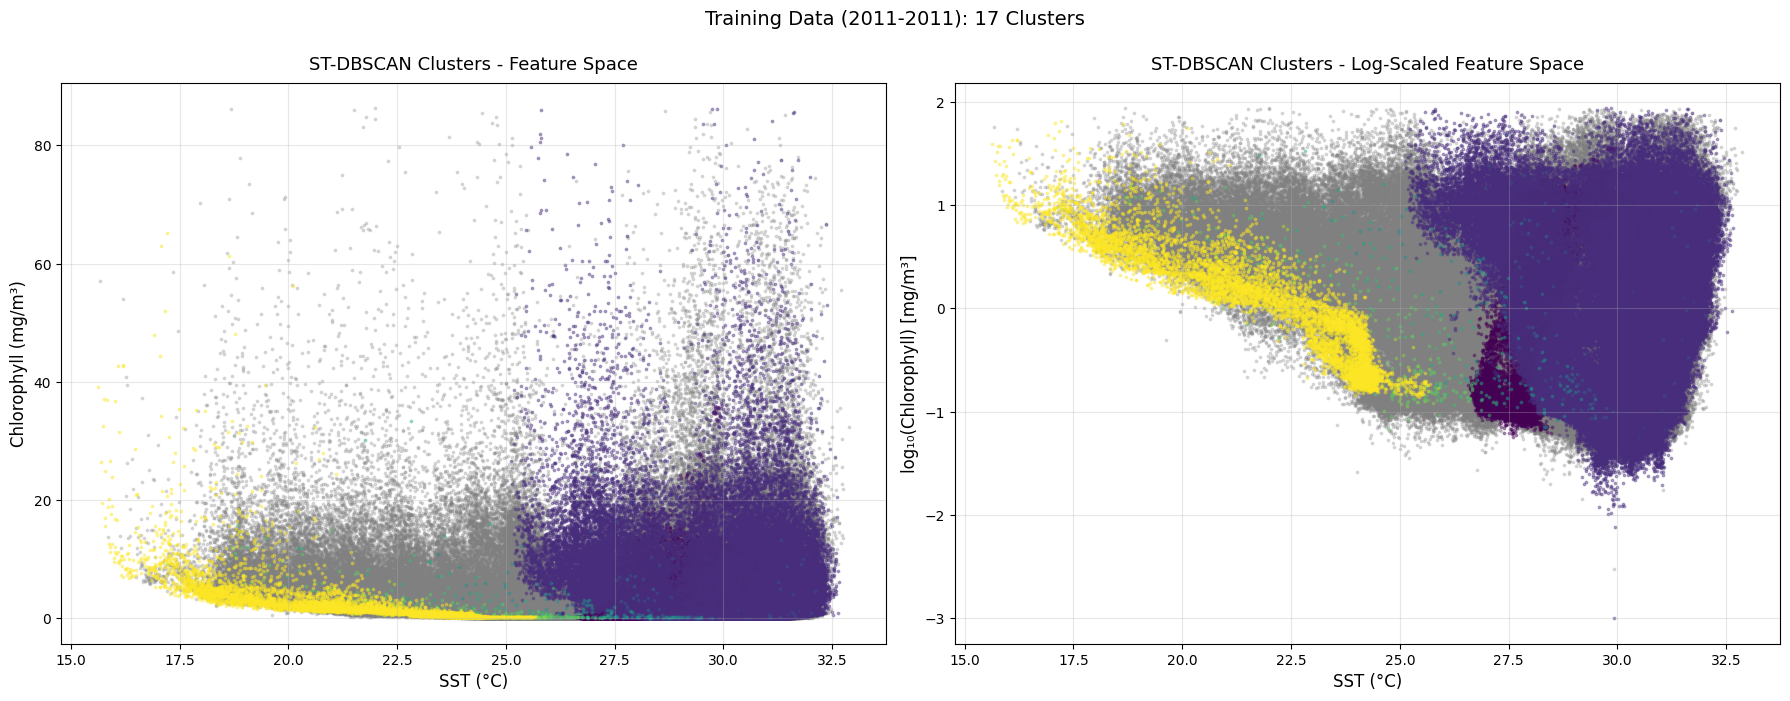

In [4]:
# Visualize feature space
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Linear scale
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
    axes[0].scatter(sst_train[mask], chlor_train[mask], 
                    alpha=0.4 if cl != -1 else 0.25, s=3, color=color, label=label_text)

axes[0].set_xlabel('SST (°C)', fontsize=12)
axes[0].set_ylabel('Chlorophyll (mg/m³)', fontsize=12)
axes[0].set_title('ST-DBSCAN Clusters - Feature Space', fontsize=13, pad=10)
axes[0].grid(True, alpha=0.3)
# axes[0].legend(loc='best', fontsize=9, markerscale=3)

# Right: Log-transformed chlorophyll
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
    axes[1].scatter(sst_train[mask], np.log10(chlor_train[mask]), 
                    alpha=0.4 if cl != -1 else 0.25, s=3, color=color, label=label_text)

axes[1].set_xlabel('SST (°C)', fontsize=12)
axes[1].set_ylabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
axes[1].set_title('ST-DBSCAN Clusters - Log-Scaled Feature Space', fontsize=13, pad=10)
axes[1].grid(True, alpha=0.3)
# axes[1].legend(loc='best', fontsize=9, markerscale=3)

plt.suptitle(f'Training Data ({training_years[0]}-{training_years[-1]}): {n_clusters} Clusters', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

In [5]:
# Print detailed cluster statistics
print("\n" + "=" * 80)
print("TRAINING DATA CLUSTER STATISTICS")
print("=" * 80)

for label in sorted(set(training_labels)):
    mask = training_labels == label
    time_cluster = time_train[mask]
    sst_cluster = sst_train[mask]
    chlor_cluster = chlor_train[mask]
    
    if label == -1:
        print(f"\n⚪ Noise Points:")
    else:
        print(f"\n🔵 Cluster {label}:")
    
    print(f"  Points: {mask.sum():,} ({100*mask.sum()/len(mask):.1f}%)")
    print(f"  Time Range: {time_cluster.min():.1f} to {time_cluster.max():.1f} days")
    print(f"              Duration: {time_cluster.max() - time_cluster.min():.1f} days")
    print(f"  SST: {sst_cluster.mean():.2f} ± {sst_cluster.std():.2f} °C")
    print(f"       Range: [{sst_cluster.min():.2f}, {sst_cluster.max():.2f}] °C")
    print(f"  Chlorophyll: {chlor_cluster.mean():.6f} ± {chlor_cluster.std():.6f} mg/m³")
    print(f"               Range: [{chlor_cluster.min():.6f}, {chlor_cluster.max():.6f}] mg/m³")

print("\n" + "=" * 80)


TRAINING DATA CLUSTER STATISTICS

⚪ Noise Points:
  Points: 346,651 (70.0%)
  Time Range: 0.0 to 182.0 days
              Duration: 182.0 days
  SST: 27.36 ± 2.97 °C
       Range: [15.68, 32.88] °C
  Chlorophyll: 3.276139 ± 6.363103 mg/m³
               Range: [0.003003, 86.246490] mg/m³

🔵 Cluster 0:
  Points: 10,107 (2.0%)
  Time Range: 0.0 to 4.0 days
              Duration: 4.0 days
  SST: 27.85 ± 0.66 °C
       Range: [26.57, 30.41] °C
  Chlorophyll: 2.168731 ± 3.858719 mg/m³
               Range: [0.057166, 25.124931] mg/m³

🔵 Cluster 2:
  Points: 131 (0.0%)
  Time Range: 3.0 to 33.0 days
              Duration: 30.0 days
  SST: 30.28 ± 0.69 °C
       Range: [29.40, 32.21] °C
  Chlorophyll: 14.788759 ± 11.555910 mg/m³
               Range: [1.549264, 36.221066] mg/m³

🔵 Cluster 3:
  Points: 130,878 (26.4%)
  Time Range: 33.0 to 113.0 days
              Duration: 80.0 days
  SST: 29.72 ± 1.34 °C
       Range: [25.13, 32.66] °C
  Chlorophyll: 3.175686 ± 6.116988 mg/m³
            

## 4. Apply Model to New Data

Select a time period to apply the trained ST-DBSCAN clustering model.

In [6]:
# Configuration for new data
apply_year = 2009
apply_start = '2009-07-01'
apply_end = '2009-07-31'

sst_var = 'analysed_sst'
chlor_var = 'chlor_a'
chlor_group = 'geophysical_data'

sst_base_pattern = r"E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_{year}-06-01_{year}-11-30"
chlor_base_pattern = r"E:\satdata\Texas Louisiana Shelf_{year}-06-01_{year}-11-30"

print(f"Applying ST-DBSCAN model to: {apply_start} to {apply_end}")

Applying ST-DBSCAN model to: 2009-07-01 to 2009-07-31


In [7]:
# Load SST data for the period
print("\n" + "=" * 80)
print("LOADING SST DATA")
print("=" * 80)

sst_dir = sst_base_pattern.format(year=apply_year)
all_sst_files = sorted(glob.glob(os.path.join(sst_dir, '*.nc')))
print(f"  Total SST files in {apply_year}: {len(all_sst_files)}")

# Filter by date
sst_files = []
sst_times = []
for sst_file in all_sst_files:
    try:
        with xr.open_dataset(sst_file) as ds:
            file_time = pd.to_datetime(ds.time.values[0])
            if pd.Timestamp(apply_start) <= file_time <= pd.Timestamp(apply_end):
                sst_files.append(sst_file)
                sst_times.append(file_time)
    except:
        continue

print(f"  Files in period: {len(sst_files)}")

# Load datasets
sst_loader = L3DatasetLoader(variables=[sst_var], bbox=(lon_min, lon_max, lat_min, lat_max))
sst_datasets = sst_loader.load_multiple(sst_files)

# Process SST and build temporal data
sst_list = []
time_indices_new = []
start_time = sst_times[0]

for idx, (ds, file_time) in enumerate(zip(sst_datasets, sst_times)):
    sst_k = ds[sst_var].values.squeeze()
    sst_c = sst_k - 273.15
    sst_c[(sst_c < -2) | (sst_c > 35)] = np.nan
    sst_list.append(sst_c)
    
    # Calculate days since start
    days_since_start = (file_time - start_time).days
    time_indices_new.append(days_since_start)

lat_sst = sst_datasets[0]['lat'].values
lon_sst = sst_datasets[0]['lon'].values

print(f"  Time range: {time_indices_new[0]} to {time_indices_new[-1]} days")
print(f"  Loaded {len(sst_list)} SST time steps")


LOADING SST DATA
  Total SST files in 2009: 184
  Files in period: 30
  Time range: 0 to 29 days
  Loaded 30 SST time steps


In [8]:
# Load chlorophyll data for the period
print("\n" + "=" * 80)
print("LOADING CHLOROPHYLL DATA")
print("=" * 80)

chlor_dir = chlor_base_pattern.format(year=apply_year)
all_chlor_files = glob.glob(os.path.join(chlor_dir, '**', '*.nc'), recursive=True)
print(f"  Total chlorophyll files in {apply_year}: {len(all_chlor_files)}")

# Group by date
chlor_by_date = {}
for chlor_file in all_chlor_files:
    filename = os.path.basename(chlor_file)
    try:
        if 'AQUA_MODIS' in filename or 'MODIS' in filename:
            parts = filename.split('.')
            if len(parts) > 1:
                date_str = parts[1][:8]
                file_date = pd.to_datetime(date_str, format='%Y%m%d')
                if pd.Timestamp(apply_start) <= file_date <= pd.Timestamp(apply_end):
                    date_key = date_str
                    if date_key not in chlor_by_date:
                        chlor_by_date[date_key] = []
                    chlor_by_date[date_key].append(chlor_file)
    except:
        continue

print(f"  Unique dates in period: {len(chlor_by_date)}")


LOADING CHLOROPHYLL DATA
  Total chlorophyll files in 2009: 284
  Unique dates in period: 31


In [9]:
# Grid data and prepare temporal features
print("\n" + "=" * 80)
print("GRIDDING AND TEMPORAL PROCESSING")
print("=" * 80)

lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)
temporal_data_new = []

# Process each time step
for time_idx, (sst_data, time_val, file_time) in enumerate(zip(sst_list, time_indices_new, sst_times)):
    # Resample SST to grid
    sst_interpolator = RegularGridInterpolator(
        (lat_sst, lon_sst), 
        sst_data,
        method='linear',
        bounds_error=False,
        fill_value=np.nan
    )
    
    points = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])
    sst_regridded = sst_interpolator(points).reshape(lat_bins, lon_bins)
    
    # Get chlorophyll for this date
    date_key = file_time.strftime('%Y%m%d')
    
    if date_key in chlor_by_date:
        try:
            chlor_loader = L2DatasetLoader(variables=[chlor_var], group=chlor_group)
            date_files = chlor_by_date[date_key][:10]  # Limit files
            chlor_datasets = chlor_loader.load_multiple(date_files)
            
            # Extract chlorophyll
            try:
                extractor = GPUDataExtractor(variables=[chlor_var])
                lon_chlor, lat_chlor, chlor_data = extractor.extract(chlor_datasets)
                chlor_flat = chlor_data[chlor_var]
            except:
                all_lons, all_lats, all_chlor = [], [], []
                for ds in chlor_datasets:
                    lat = ds['lat'].values.flatten()
                    lon = ds['lon'].values.flatten()
                    chlor = ds[chlor_var].values.flatten()
                    valid = (~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(chlor) & (chlor > 0))
                    all_lats.extend(lat[valid])
                    all_lons.extend(lon[valid])
                    all_chlor.extend(chlor[valid])
                lat_chlor = np.array(all_lats)
                lon_chlor = np.array(all_lons)
                chlor_flat = np.array(all_chlor)
            
            # Clip and grid
            clip_mask = ((lon_chlor >= lon_min) & (lon_chlor <= lon_max) &
                        (lat_chlor >= lat_min) & (lat_chlor <= lat_max))
            
            chlor_binned, _, _, _ = binned_statistic_2d(
                lat_chlor[clip_mask], lon_chlor[clip_mask], chlor_flat[clip_mask],
                statistic='mean',
                bins=[lat_bins, lon_bins],
                range=[[lat_min, lat_max], [lon_min, lon_max]]
            )
        except:
            chlor_binned = np.full((lat_bins, lon_bins), np.nan)
    else:
        chlor_binned = np.full((lat_bins, lon_bins), np.nan)
    
    # Extract valid pixels
    valid_mask = ~np.isnan(sst_regridded) & ~np.isnan(chlor_binned)
    n_valid = np.sum(valid_mask)
    
    if n_valid > 0:
        sst_valid = sst_regridded[valid_mask]
        chlor_valid = chlor_binned[valid_mask]
        
        # Create feature vectors: [time, sst, chlor]
        time_vec = np.full(n_valid, time_val)
        features = np.column_stack([time_vec, sst_valid, chlor_valid])
        temporal_data_new.append(features)
    
    print(f"  Time step {time_idx+1}/{len(sst_list)}: {n_valid} valid pixels")

# Combine all temporal data
data_new = np.vstack(temporal_data_new)

print(f"\n  Total data points: {len(data_new):,}")
print(f"  Time range: {data_new[:, 0].min():.1f} to {data_new[:, 0].max():.1f} days")
print(f"  SST range: {data_new[:, 1].min():.2f} to {data_new[:, 1].max():.2f} °C")
print(f"  Chlor range: {data_new[:, 2].min():.4f} to {data_new[:, 2].max():.4f} mg/m³")


GRIDDING AND TEMPORAL PROCESSING
  Time step 1/30: 3623 valid pixels
  Time step 2/30: 2662 valid pixels
  Time step 3/30: 10139 valid pixels
  Time step 4/30: 2647 valid pixels
  Time step 5/30: 1732 valid pixels
  Time step 6/30: 72 valid pixels
  Time step 7/30: 233 valid pixels
  Time step 8/30: 4165 valid pixels
  Time step 9/30: 978 valid pixels
  Time step 10/30: 5208 valid pixels
  Time step 11/30: 3633 valid pixels
  Time step 12/30: 3973 valid pixels
  Time step 13/30: 3863 valid pixels
  Time step 14/30: 722 valid pixels
  Time step 15/30: 1015 valid pixels
  Time step 16/30: 1178 valid pixels
  Time step 17/30: 33 valid pixels
  Time step 18/30: 117 valid pixels
  Time step 19/30: 1949 valid pixels
  Time step 20/30: 7073 valid pixels
  Time step 21/30: 7707 valid pixels
  Time step 22/30: 509 valid pixels
  Time step 23/30: 797 valid pixels
  Time step 24/30: 1873 valid pixels
  Time step 25/30: 1739 valid pixels
  Time step 26/30: 4409 valid pixels
  Time step 27/30: 862

In [12]:
# Apply ST-DBSCAN clustering
print("\n" + "=" * 80)
print("APPLYING ST-DBSCAN MODEL")
print("=" * 80)

if len(data_new) > 0:
    # Normalize features (excluding time)
    data_normalized_new = data_new.copy()
    data_normalized_new[:, 1:] = scaler.transform(data_new[:, 1:])
    
    # Ensure data types are correct (float64)
    data_normalized_new = data_normalized_new.astype(np.float64)
    
    print(f"  Data shape: {data_normalized_new.shape}")
    print(f"  Data dtype: {data_normalized_new.dtype}")
    print(f"  Time range: {data_normalized_new[:, 0].min():.1f} to {data_normalized_new[:, 0].max():.1f} days")
    
    # Apply clustering using frame-based method (more memory efficient and stable)
    frame_size = int(eps2 * 3)  # Process 3x temporal window at a time
    frame_overlap = eps2  # Overlap by temporal threshold
    
    print(f"  Using fit_frame_split() with frame_size={frame_size} days")
    
    st_dbscan_new = ST_DBSCAN(eps1=eps1, eps2=eps2, min_samples=min_samples, n_jobs=-1)
    st_dbscan_new.fit_frame_split(data_normalized_new, frame_size=frame_size, frame_overlap=frame_overlap)
    labels_new = st_dbscan_new.labels
    
    n_clusters_found = len(set(labels_new)) - (1 if -1 in labels_new else 0)
    n_noise = np.sum(labels_new == -1)
    
    print(f"  Clusters found: {n_clusters_found}")
    print(f"  Noise points: {n_noise} ({100*n_noise/len(labels_new):.1f}%)")
    
    # Extract features
    time_new = data_new[:, 0]
    sst_new = data_new[:, 1]
    chlor_new = data_new[:, 2]
else:
    print("  ⚠ No valid data to cluster")
    labels_new = np.array([])


APPLYING ST-DBSCAN MODEL
  Data shape: (82748, 3)
  Data dtype: float64
  Time range: 0.0 to 29.0 days
  Using fit_frame_split() with frame_size=27 days
  Clusters found: 9
  Noise points: 58778 (71.0%)
  Clusters found: 9
  Noise points: 58778 (71.0%)


## 5. Visualize Results

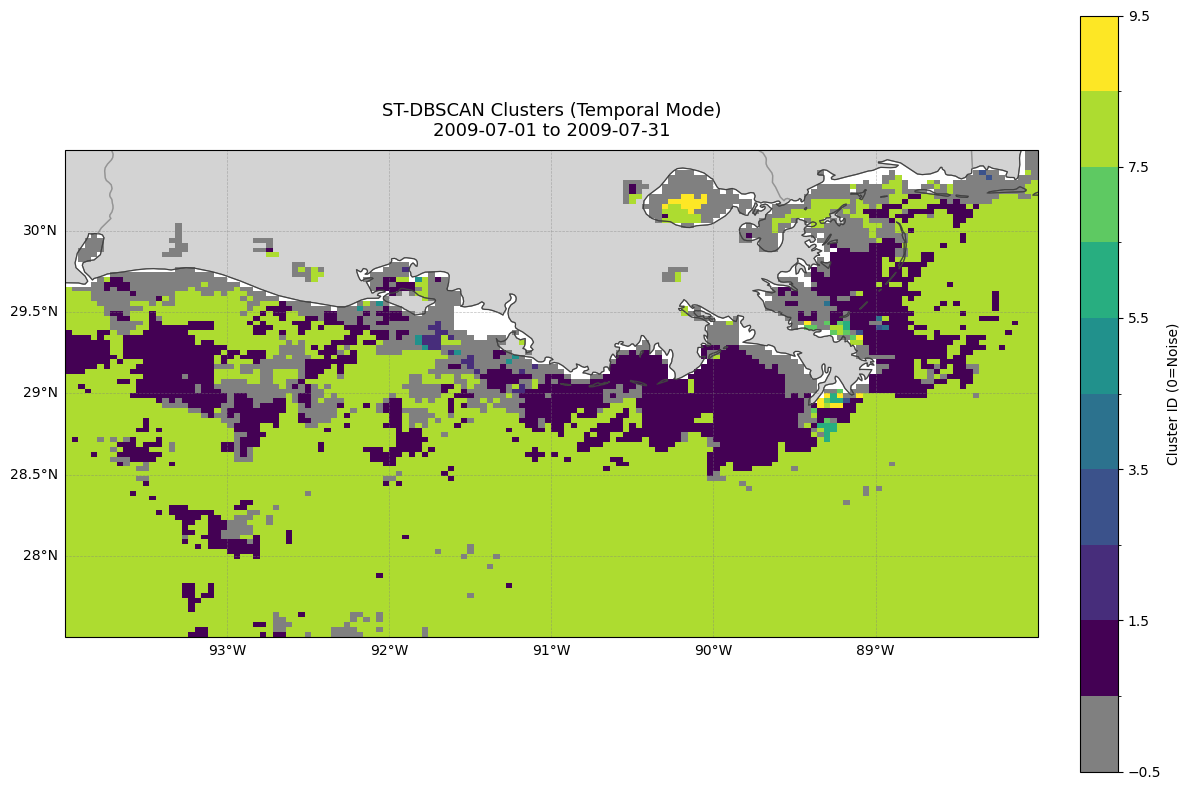


✓ Map shows temporal mode (most frequent cluster) for each pixel across 30 time steps


In [17]:
# Create spatial map of clusters for the new data
if len(data_new) > 0 and n_valid > 0:
    # Reconstruct spatial cluster map from temporal data
    # We need to aggregate clusters across time for visualization
    
    # Create empty grid for each time step
    cluster_maps_timesteps = []
    
    # Track position in data_new array
    data_idx = 0
    
    for time_step in range(len(sst_list)):
        cluster_map_t = np.full((lat_bins, lon_bins), np.nan)
        
        # Find data points for this time step
        time_val = time_indices_new[time_step]
        time_mask = (data_new[:, 0] == time_val)
        n_points_t = np.sum(time_mask)
        
        if n_points_t > 0:
            # Get the corresponding cluster labels
            labels_t = labels_new[time_mask]
            
            # Get SST and chlor for this timestep to find valid pixels
            sst_t = sst_list[time_step]
            
            # Resample SST to grid
            sst_interpolator = RegularGridInterpolator(
                (lat_sst, lon_sst), sst_t,
                method='linear', bounds_error=False, fill_value=np.nan
            )
            points = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])
            sst_regridded_t = sst_interpolator(points).reshape(lat_bins, lon_bins)
            
            # Get chlorophyll for this date
            date_key = sst_times[time_step].strftime('%Y%m%d')
            if date_key in chlor_by_date:
                try:
                    chlor_loader_t = L2DatasetLoader(variables=[chlor_var], group=chlor_group)
                    date_files = chlor_by_date[date_key][:10]
                    chlor_datasets_t = chlor_loader_t.load_multiple(date_files)
                    
                    try:
                        extractor_t = GPUDataExtractor(variables=[chlor_var])
                        lon_chlor_t, lat_chlor_t, chlor_data_t = extractor_t.extract(chlor_datasets_t)
                        chlor_flat_t = chlor_data_t[chlor_var]
                    except:
                        all_lons_t, all_lats_t, all_chlor_t = [], [], []
                        for ds in chlor_datasets_t:
                            lat_t = ds['lat'].values.flatten()
                            lon_t = ds['lon'].values.flatten()
                            chlor_t = ds[chlor_var].values.flatten()
                            valid_t = (~np.isnan(lat_t) & ~np.isnan(lon_t) & ~np.isnan(chlor_t) & (chlor_t > 0))
                            all_lats_t.extend(lat_t[valid_t])
                            all_lons_t.extend(lon_t[valid_t])
                            all_chlor_t.extend(chlor_t[valid_t])
                        lat_chlor_t = np.array(all_lats_t)
                        lon_chlor_t = np.array(all_lons_t)
                        chlor_flat_t = np.array(all_chlor_t)
                    
                    clip_mask_t = ((lon_chlor_t >= lon_min) & (lon_chlor_t <= lon_max) &
                                  (lat_chlor_t >= lat_min) & (lat_chlor_t <= lat_max))
                    
                    chlor_binned_t, _, _, _ = binned_statistic_2d(
                        lat_chlor_t[clip_mask_t], lon_chlor_t[clip_mask_t], chlor_flat_t[clip_mask_t],
                        statistic='mean', bins=[lat_bins, lon_bins],
                        range=[[lat_min, lat_max], [lon_min, lon_max]]
                    )
                except:
                    chlor_binned_t = np.full((lat_bins, lon_bins), np.nan)
            else:
                chlor_binned_t = np.full((lat_bins, lon_bins), np.nan)
            
            # Find valid pixels and assign labels
            valid_mask_t = ~np.isnan(sst_regridded_t) & ~np.isnan(chlor_binned_t)
            
            # Assign labels to valid pixels
            label_idx = 0
            for i in range(lat_bins):
                for j in range(lon_bins):
                    if valid_mask_t[i, j]:
                        if label_idx < len(labels_t):
                            cluster_map_t[i, j] = labels_t[label_idx]
                            label_idx += 1
        
        cluster_maps_timesteps.append(cluster_map_t)
    
    # Compute temporal mode (most frequent NON-NOISE cluster) for each pixel
    # Only show cluster if it appears in at least this fraction of valid timesteps
    cluster_threshold = 0.1  # 30% of timesteps must have the cluster
    
    cluster_map_mode = np.full((lat_bins, lon_bins), np.nan)
    
    for i in range(lat_bins):
        for j in range(lon_bins):
            pixel_labels = [cm[i, j] for cm in cluster_maps_timesteps if not np.isnan(cm[i, j])]
            if len(pixel_labels) > 0:
                # Filter out noise (-1) and get most common non-noise cluster
                non_noise_labels = [lbl for lbl in pixel_labels if lbl != -1]
                
                if len(non_noise_labels) > 0:
                    unique_vals, counts = np.unique(non_noise_labels, return_counts=True)
                    most_common_cluster = unique_vals[np.argmax(counts)]
                    most_common_count = counts[np.argmax(counts)]
                    
                    # Only assign cluster if it meets threshold
                    if most_common_count / len(pixel_labels) >= cluster_threshold:
                        cluster_map_mode[i, j] = most_common_cluster
                    else:
                        cluster_map_mode[i, j] = -1  # Mark as noise if below threshold
                else:
                    cluster_map_mode[i, j] = -1  # All timesteps were noise
    
    # Create visualization
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Prepare plot data
    unique_labels_new = sorted(set(labels_new))
    cluster_labels_new = [l for l in unique_labels_new if l != -1]
    cluster_labels_sorted_new = sorted(cluster_labels_new)
    
    # Create colormap
    palette_new = plt.cm.viridis(np.linspace(0, 1, len(cluster_labels_sorted_new)))
    cmap_colors_new = ['#808080'] + [rgb2hex(c) for c in palette_new]
    cmap_new = ListedColormap(cmap_colors_new)
    bounds_new = np.arange(0, len(cluster_labels_sorted_new) + 2) - 0.5
    norm_new = BoundaryNorm(bounds_new, cmap_new.N)
    
    # Map labels to plot indices
    plot_map = np.full_like(cluster_map_mode, np.nan)
    for i in range(lat_bins):
        for j in range(lon_bins):
            if not np.isnan(cluster_map_mode[i, j]):
                label_val = cluster_map_mode[i, j]
                if label_val == -1:
                    plot_map[i, j] = 0  # Noise
                elif label_val in cluster_labels_sorted_new:
                    plot_map[i, j] = cluster_labels_sorted_new.index(label_val) + 1
    
    # Plot
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    cluster_plot = ax.pcolormesh(lon_edges, lat_edges, plot_map,
                                 cmap=cmap_new, norm=norm_new, shading='auto',
                                 transform=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = gl.right_labels = False
    
    plt.colorbar(cluster_plot, ax=ax, fraction=0.046, pad=0.04, 
                 label='Cluster ID (0=Noise)')
    ax.set_title(f'ST-DBSCAN Clusters (Temporal Mode)\n{apply_start} to {apply_end}', 
                 fontsize=13, pad=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Map shows temporal mode (most frequent cluster) for each pixel across {len(sst_list)} time steps")
else:
    print("No data to visualize")

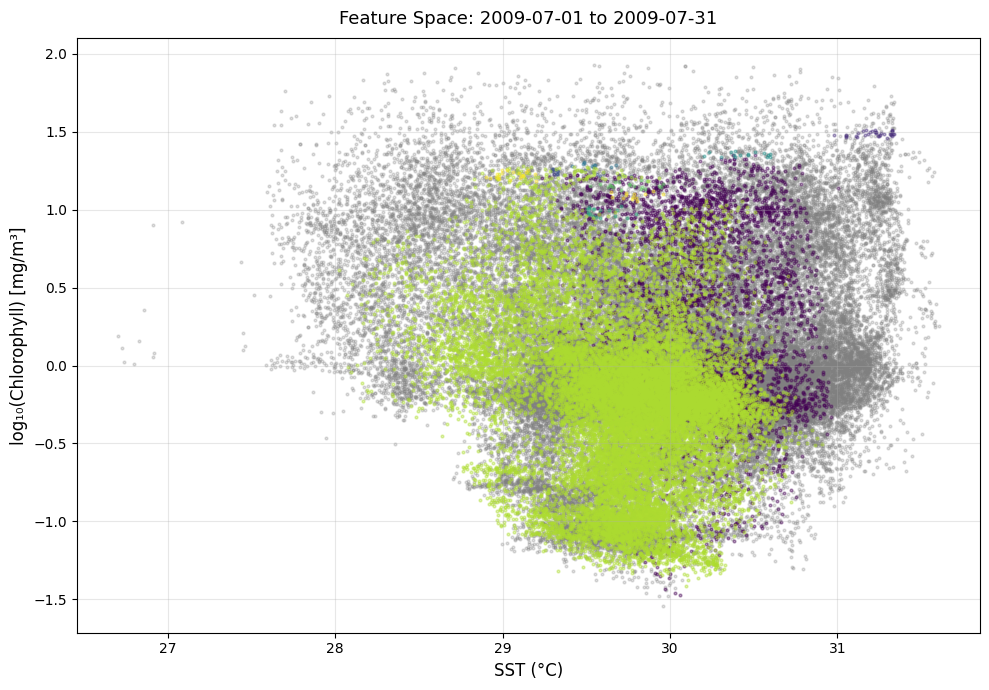

In [13]:
# Visualize feature space for new data
if len(data_new) > 0:
    # Create colors for new clusters
    unique_labels_new = sorted(set(labels_new))
    cluster_labels_new = [l for l in unique_labels_new if l != -1]
    palette_new = plt.cm.viridis(np.linspace(0, 1, len(cluster_labels_new)))
    colors_map_new = {-1: '#808080'}
    for i, cl in enumerate(sorted(cluster_labels_new)):
        colors_map_new[cl] = rgb2hex(palette_new[i])
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    
    for cl in unique_labels_new:
        mask = labels_new == cl
        color = colors_map_new.get(cl, '#808080')
        label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
        ax.scatter(sst_new[mask], np.log10(chlor_new[mask]), 
                   alpha=0.4 if cl != -1 else 0.25, s=4, color=color, label=label_text)
    
    ax.set_xlabel('SST (°C)', fontsize=12)
    ax.set_ylabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
    ax.set_title(f'Feature Space: {apply_start} to {apply_end}', fontsize=13, pad=10)
    ax.grid(True, alpha=0.3)
    # ax.legend(loc='best', fontsize=10, markerscale=2)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize")

In [14]:
# Print cluster statistics for new data
if len(data_new) > 0:
    print("\n" + "=" * 80)
    print(f"CLUSTER STATISTICS: {apply_start.upper()} TO {apply_end.upper()}")
    print("=" * 80)
    
    for label in sorted(set(labels_new)):
        mask = labels_new == label
        time_cluster = time_new[mask]
        sst_cluster = sst_new[mask]
        chlor_cluster = chlor_new[mask]
        
        if label == -1:
            print(f"\n⚪ Noise Points:")
        else:
            print(f"\n🔵 Cluster {label}:")
        
        print(f"  Points: {mask.sum():,} ({100*mask.sum()/len(mask):.1f}%)")
        print(f"  Time Range: {time_cluster.min():.1f} to {time_cluster.max():.1f} days")
        print(f"              Duration: {time_cluster.max() - time_cluster.min():.1f} days")
        print(f"  SST: {sst_cluster.mean():.2f} ± {sst_cluster.std():.2f} °C")
        print(f"       Range: [{sst_cluster.min():.2f}, {sst_cluster.max():.2f}] °C")
        print(f"  Chlorophyll: {chlor_cluster.mean():.6f} ± {chlor_cluster.std():.6f} mg/m³")
        print(f"               Range: [{chlor_cluster.min():.6f}, {chlor_cluster.max():.6f}] mg/m³")
    
    print("\n" + "=" * 80)


CLUSTER STATISTICS: 2009-07-01 TO 2009-07-31

⚪ Noise Points:
  Points: 58,778 (71.0%)
  Time Range: 0.0 to 29.0 days
              Duration: 29.0 days
  SST: 29.92 ± 0.74 °C
       Range: [26.70, 31.61] °C
  Chlorophyll: 3.341260 ± 6.172032 mg/m³
               Range: [0.028823, 84.729248] mg/m³

🔵 Cluster 0:
  Points: 3,525 (4.3%)
  Time Range: 0.0 to 0.0 days
              Duration: 0.0 days
  SST: 30.26 ± 0.33 °C
       Range: [29.23, 31.00] °C
  Chlorophyll: 4.230490 ± 4.701394 mg/m³
               Range: [0.033935, 22.398173] mg/m³

🔵 Cluster 1:
  Points: 32 (0.0%)
  Time Range: 2.0 to 2.0 days
              Duration: 0.0 days
  SST: 31.22 ± 0.10 °C
       Range: [30.98, 31.34] °C
  Chlorophyll: 30.628793 ± 0.966205 mg/m³
               Range: [28.990530, 32.297033] mg/m³

🔵 Cluster 2:
  Points: 18 (0.0%)
  Time Range: 2.0 to 2.0 days
              Duration: 0.0 days
  SST: 29.46 ± 0.16 °C
       Range: [29.29, 29.77] °C
  Chlorophyll: 17.315281 ± 0.570620 mg/m³
               R

## 6. Summary

The trained ST-DBSCAN model identifies oceanic regimes based on SST and chlorophyll patterns that persist over time. The model was trained on 2005-2011 data and can be applied to any new time period with SST and chlorophyll measurements.

**Next Steps:**
- Apply to different time periods
- Compare cluster distributions across seasons/years
- Analyze environmental drivers of each cluster
- Export cluster masks for further analysis